## - Import

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_audit import audit_reviews, print_audit
from src.cleaning import clean_reviews

## Load Notebook

In [2]:
RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bca_mobile_reviews_raw.csv"
)

df_raw = pd.read_csv(RAW_PATH)

print(f"Raw dataset: {df_raw.shape[0]:,} rows")
print(f"Columns: {list(df_raw.columns)}")

df_raw.head()

Raw dataset: 5,000 rows
Columns: ['review_id', 'rating', 'review_date', 'review_text', 'thumbs_up']


,review_id,rating,review_date,review_text,thumbs_up
0,e008717e-e489-4495-8377-10ac8acde670,1,2026-08-18 00:27:56,mbking gua gak bisa jadi gua kasih bintang 1 p...,0
1,1fc5fd68-bd82-409e-aa57-f8474c09e6c6,5,2026-08-17 23:15:59,Bagus,0
2,4faf44fa-cdf4-48ce-9e09-4eb66abed001,5,2026-08-17 23:08:11,kenapa dihp sy gak bisa didonlot ya bca mobile...,0
3,803a2c46-325f-4b78-a400-3c6403664096,5,2026-08-17 22:35:31,Lancar utk transfer.,0
4,fab4ca0b-fbaa-4388-85ea-3452d274b269,2,2026-08-17 22:34:24,aplikasi nya susah di buka ngembal terus. masa...,0


## Audit Raw Data

In [3]:
raw_audit = audit_reviews(df_raw)

print_audit(raw_audit)


DATA QUALITY AUDIT
Rows: 5,000
Columns: 5

Duplicate review IDs: 0
Duplicate review text: 755
Empty reviews: 0
Invalid ratings: 0
Invalid dates: 0

Date range:
  2026-05-01 07:42:02 → 2026-08-18 00:27:56

Rating distribution:
  1 star: 1,931
  2 star: 382
  3 star: 332
  4 star: 266
  5 star: 2,089

Missing values:
  review_id: 0
  rating: 0
  review_date: 0
  review_text: 0
  thumbs_up: 0


## Duplicate Text: Raw Count vs. True Duplicates

`audit_reviews()` flags `duplicate_review_text` whenever the same review text appears more than once,
**regardless of date**. On a review platform this is expected to be noisy: many users independently
write short reviews like "Bagus" or "mantap" without copying each other.

`clean_reviews()` is stricter — it only drops rows where **both** `review_text` and `review_date`
match exactly (same second), which is a much stronger signal of an actual scraping/collection duplicate
rather than two different users happening to write the same word.

The gap between these two numbers tells us how much of the "duplicate text" audit finding is just
short, common phrasing rather than a real data quality problem.

In [4]:
dup_text_only = df_raw["review_text"].duplicated().sum()
dup_text_and_date = df_raw.duplicated(subset=["review_text", "review_date"]).sum()

print(f"Reviews with duplicate text (any date):      {dup_text_only:,}")
print(f"Reviews with duplicate text AND duplicate date: {dup_text_and_date:,}")
print(f"Difference (likely just common short phrasing): {dup_text_only - dup_text_and_date:,}")

Reviews with duplicate text (any date):      755
Reviews with duplicate text AND duplicate date: 0
Difference (likely just common short phrasing): 755


## Clean Reviews

In [5]:
df = clean_reviews(df_raw)

print(f"Rows before cleaning: {len(df_raw):,}")
print(f"Rows after cleaning:  {len(df):,}")
print(f"Removed:              {len(df_raw) - len(df):,}")

Rows before cleaning: 5,000
Rows after cleaning:  5,000
Removed:              0


## Cleaned Data Audit

In [6]:
clean_audit = audit_reviews(df)

print_audit(clean_audit)


DATA QUALITY AUDIT
Rows: 5,000
Columns: 5

Duplicate review IDs: 0
Duplicate review text: 755
Empty reviews: 0
Invalid ratings: 0
Invalid dates: 0

Date range:
  2026-05-01 07:42:02 → 2026-08-18 00:27:56

Rating distribution:
  1 star: 1,931
  2 star: 382
  3 star: 332
  4 star: 266
  5 star: 2,089

Missing values:
  review_id: 0
  rating: 0
  review_date: 0
  review_text: 0
  thumbs_up: 0


## Sanity Checks (Post-Cleaning)

These assertions confirm `clean_reviews()` actually did its job — no invalid ratings, no invalid dates,
no empty text, and no duplicate IDs should remain. This is a regression guard: if `cleaning.py` changes
later and breaks something, this cell fails loudly instead of the issue silently passing through to
downstream notebooks.

In [7]:
assert clean_audit["duplicate_review_ids"] in (0, None), "Duplicate review IDs remain after cleaning"
assert clean_audit["invalid_ratings"] == 0, "Invalid ratings remain after cleaning"
assert clean_audit["invalid_dates"] == 0, "Invalid dates remain after cleaning"
assert clean_audit["empty_reviews"] == 0, "Empty reviews remain after cleaning"

print("All post-cleaning sanity checks passed.")

All post-cleaning sanity checks passed.


## Save Cleaned Dataset

Persisting the cleaned dataset here (instead of re-running `clean_reviews()` in every later notebook)
keeps `02_exploratory_analysis.ipynb` and beyond working from one canonical, already-validated file,
rather than each notebook silently re-deriving its own copy that could drift out of sync.

In [8]:
INTERIM_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "bca_mobile_reviews_clean.csv"
)

INTERIM_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(INTERIM_PATH, index=False)

print(f"Saved cleaned dataset: {len(df):,} rows -> {INTERIM_PATH.relative_to(PROJECT_ROOT)}")

Saved cleaned dataset: 5,000 rows -> data\interim\bca_mobile_reviews_clean.csv


## Rating distribution

In [9]:
df["rating"].value_counts().sort_index()

rating
1    1931
2     382
3     332
4     266
5    2089
Name: count, dtype: int64

## Date range

In [10]:
print("Earliest:", df["review_date"].min())
print("Latest:  ", df["review_date"].max())

Earliest: 2026-05-01 07:42:02
Latest:   2026-08-18 00:27:56


## Reviews per month

In [11]:
monthly_reviews = (
    df.set_index("review_date")
      .resample("ME")
      .size()
)

monthly_reviews

review_date
2026-05-31    1845
2026-06-30     964
2026-07-31     964
2026-08-31    1227
Freq: ME, dtype: int64

## Average rating by month

In [12]:
monthly_rating = (
    df.set_index("review_date")["rating"]
      .resample("ME")
      .mean()
)

monthly_rating

review_date
2026-05-31    2.769648
2026-06-30    3.000000
2026-07-31    3.058091
2026-08-31    3.463733
Freq: ME, Name: rating, dtype: float64

## Review length

In [13]:
df["review_length"] = (
    df["review_text"]
    .str.split()
    .str.len()
)

df["review_length"].describe()

count    5000.000000
mean       13.059800
std        14.400295
min         1.000000
25%         3.000000
50%         8.000000
75%        18.000000
max        98.000000
Name: review_length, dtype: float64

In [14]:
pd.set_option(
    "display.max_colwidth",
    300,
)

df[
    [
        "review_date",
        "rating",
        "review_text",
    ]
].sample(
    min(50, len(df)),
    random_state=42,
)

,review_date,rating,review_text
1501,2026-05-26 07:55:58,1,"saya amat sangat menyayangkan untuk aplikasi bca skarang. saya datang ingin memperbaharui aplikasi krn ganti hp dri ios ke android ke 3cabang di jabodetabek , katanya sluruh cabang off CS jam 1an ke atas . saya datang di jam 9 pun keterbatasan cs . BCA sengaja banget biar gk di komplen apa giman..."
2586,2026-06-23 17:18:45,5,bagus pelayanannya
2653,2026-06-25 20:10:15,1,makin ke sini verefikasinya makin sulit contoh nya wajah GK kelihatan kameranya
1055,2026-05-18 15:46:08,1,"suka hilang sinyal, padahal buka apa aja bisa jalan"
705,2026-05-13 21:49:50,1,"pembayaran qris transaksi gagal tapi saldo kepotong, coba lapor ke WhatsApp halo BCA tapi ga ada respon sama sekali, PAYAH LAH !!!"
106,2026-05-04 04:09:56,1,GK bisa login
589,2026-05-13 15:08:24,5,BB LM bisa kebuka Buuk
2468,2026-06-20 15:13:49,1,kek puqi anj
2413,2026-06-20 14:43:11,1,sering gangguan dan lampu indikator dari hijau tiba2 langsung merah sendiri menghambat proses transaksi
1600,2026-05-26 22:27:29,5,Ribet verivikasi gagal mulu


In [15]:
df[
    df["rating"] <= 2
][
    [
        "review_date",
        "rating",
        "review_text",
    ]
].sample(
    min(
        100,
        len(df[df["rating"] <= 2])
    ),
    random_state=42,
)

,review_date,rating,review_text
3282,2026-07-16 11:43:42,2,membayar menggunakan Qris tapi lampu tetap merah dan tak kunjung hijau.
974,2026-05-16 10:22:38,1,sudah restart hp sudah hapus download lagi masih aja indikator lampu merah enggak kompeten banget sih apknya
3775,2026-08-01 01:49:54,1,lampu hijau terlalu lama menyala bikin kesal mwngganggu transaksi
103,2026-05-03 23:05:38,1,duit saya ga keluar 500rb saat penarikan di atm dan saya hubungin cs disuruh nunggu dari 3 mei samapai tanggal 8 mei lambat banget playanan nya dan ini juga belum pasti uang kembalil atau tidak. bobrok banget nih server nya bca pengen nya nagmbil duit nasabah doang layan buruk tambah lagi aplika...
3134,2026-07-12 02:33:22,1,Aplikasi kaga jelas klo malem Minggu di atas jam 12 malem kaga bisa di pake perbaikan sistem Mulu kaga jelas.mendingan bank laen
...,...,...,...
3815,2026-08-01 19:48:23,1,masa ga sesuai ketentuan katanya biaya cetak fisik 25.000 terus ada biaya mengendap okelah 10.000. lah ko jadi sering kepotong mulu gimana sih? bilang nya saldo mengendap masa saldo mengendap sampai 53.000
2262,2026-06-14 22:11:53,1,BCA sekarang sering error jika transaksi menggunakan Qris. lama juga baliknya kl gagal transaksi
2129,2026-06-09 12:26:46,1,"sekarang2 knpa jadi susah, pdhal sinyal ok, tp tetap merah ngga bisa transaksi. bukannya ngebantu, malah ngehambat."
1478,2026-05-25 17:27:51,1,minta kode otp aja pulsa habis terus kocak


## Thumbs-Up Field

`thumbs_up` isn't used yet, but it's a signal of review helpfulness/visibility that could later be used
to weight issues (e.g. "this complaint was upvoted 200 times" carries more signal than an isolated one).
Worth auditing now so we know whether it's usable before we get to prioritization.

In [16]:
if "thumbs_up" in df.columns:
    thumbs_up = pd.to_numeric(df["thumbs_up"], errors="coerce")

    print(f"Missing thumbs_up values: {thumbs_up.isna().sum():,}")
    print(f"Negative thumbs_up values: {(thumbs_up < 0).sum():,}")
    print()
    print(thumbs_up.describe())
    print()

    top_upvoted = df.assign(thumbs_up=thumbs_up).sort_values("thumbs_up", ascending=False).head(10)
    top_upvoted[["review_date", "rating", "thumbs_up", "review_text"]]
else:
    print("thumbs_up column not present in dataset.")

Missing thumbs_up values: 0
Negative thumbs_up values: 0

count    5000.000000
mean        0.195800
std         1.128413
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        24.000000
Name: thumbs_up, dtype: float64



## Very Short Reviews

Reviews that survive cleaning (non-empty) but consist of only 1-2 words (e.g. "Bagus", "ok", "jelek")
carry almost no information for issue/aspect classification later. We're **not deleting** them here —
review text is preserved per project rules — but it's useful to know how large this group is now,
since it will affect how we interpret coverage numbers once we get to issue classification
(a low-rated 1-word review can't be attributed to a specific issue, and that's expected, not a bug).

In [17]:
very_short = df[df["review_length"] <= 2]

print(f"Reviews with <=2 words: {len(very_short):,} ({len(very_short) / len(df):.1%} of cleaned dataset)")
print()
print("Rating distribution among very short reviews:")
print(very_short["rating"].value_counts().sort_index())
print()

very_short[["review_date", "rating", "review_text"]].sample(
    min(15, len(very_short)), random_state=42
)

Reviews with <=2 words: 1,235 (24.7% of cleaned dataset)

Rating distribution among very short reviews:
rating
1      88
2      20
3      18
4      54
5    1055
Name: count, dtype: int64



,review_date,rating,review_text
3269,2026-07-15 23:05:37,5,good
2662,2026-06-26 08:05:21,5,mantab
2540,2026-06-22 11:32:01,4,lancar jaya
453,2026-05-13 07:43:01,5,ok
932,2026-05-15 13:10:27,5,👍👍👍👍
2010,2026-06-05 01:14:42,1,gangguan mulu
1366,2026-05-25 12:26:59,5,mantap 👍👍👍👍👍
4299,2026-08-12 10:28:49,5,Bca okeh
1982,2026-06-04 05:34:26,5,bagus
4462,2026-08-12 18:15:50,5,bagus


## Visual Sanity Checks

Tables are enough to *read* the numbers, but a plot makes it much faster to *see* anomalies:
sudden volume spikes/drops (possible collection gaps, or a viral complaint period), rating dips
that coincide with an app update, or gaps in the timeline. These three charts exist purely to
catch data issues before we move on — not as dashboard-style visuals.

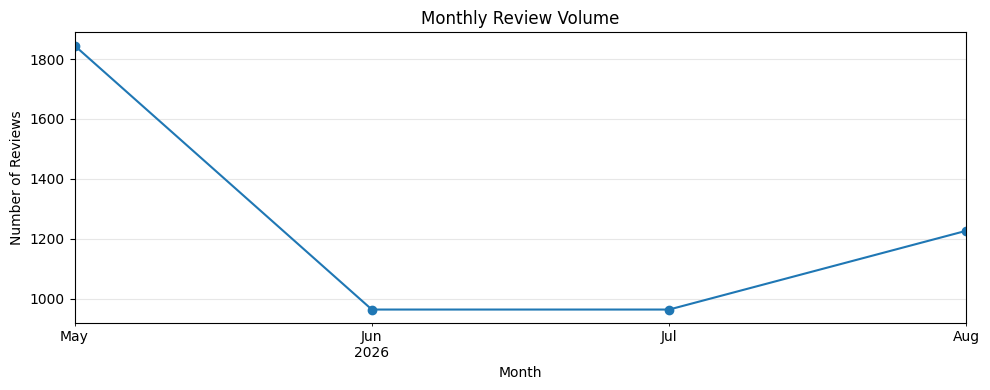

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
monthly_reviews.plot(ax=ax, marker="o")
ax.set_title("Monthly Review Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reviews")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

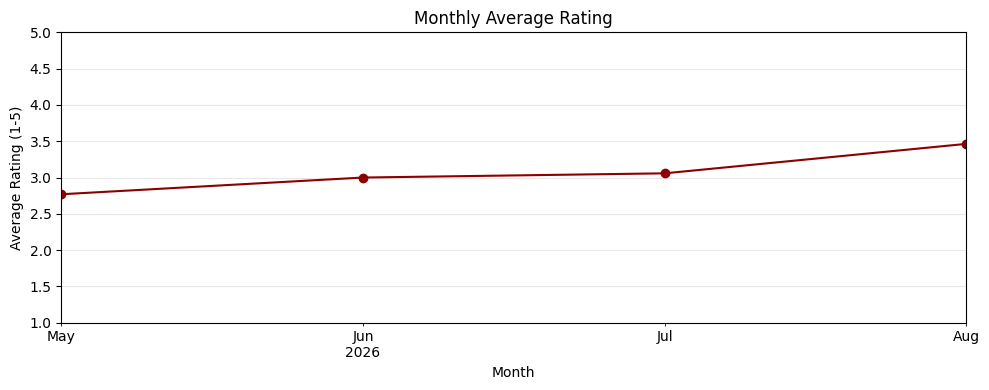

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
monthly_rating.plot(ax=ax, marker="o", color="darkred")
ax.set_title("Monthly Average Rating")
ax.set_xlabel("Month")
ax.set_ylabel("Average Rating (1-5)")
ax.set_ylim(1, 5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

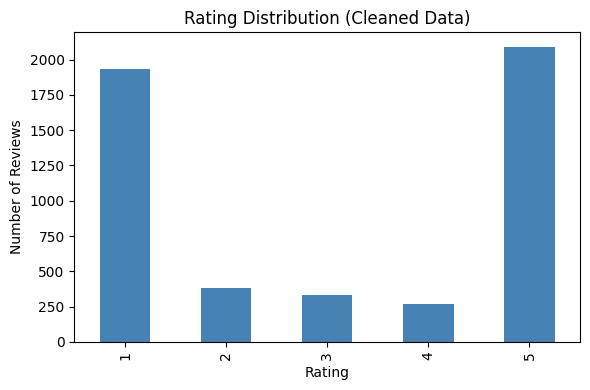

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
df["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Rating Distribution (Cleaned Data)")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Audit Findings & Next Steps

**Data quality**
- Raw rows: 5,000 → Cleaned rows: 5,000 (removed: 0). No rows failed cleaning — the dataset
  was clean at collection time.
- Duplicate text vs. duplicate text+date gap: 755 vs. 0. Confirms the "755 duplicate text"
  audit finding is entirely short common phrasing ("Bagus", "mantap") written independently by
  different users, not a real scraping/collection duplicate — no action needed.
- Invalid ratings / dates found: 0 / 0.
- thumbs_up usable for weighting later: partially. 75% of reviews have thumbs_up = 0 (median 0,
  max 24), so it's too sparse to weight the full dataset meaningfully, but it can still be used
  as a tie-breaker when ranking within an issue category (e.g. surfacing the most-upvoted example
  quote for a given complaint type).

**Coverage**
- Date range: 2026-05-01 → 2026-08-18 (~3.5 months). Enough to see a within-year trend, but not
  a full year — seasonal effects can't be ruled out.
- Monthly volume: May (1,845) is nearly double June/July (964 each), with August partial-month
  at 1,227. Worth flagging as a possible collection-order artifact rather than a real usage
  spike — not resolved here, but should be kept in mind when reading "May was worse" framing
  in later notebooks.
- % of reviews that are very short (≤2 words): 24.7% (1,235 reviews). Sets a hard ceiling on
  issue-classification coverage — roughly a quarter of the dataset carries essentially no
  attributable product signal by design, not due to a modeling gap.

**Signal**
- Rating distribution is bimodal/J-shaped (1-star: 38.6%, 5-star: 41.8%, everything else much
  smaller) — typical for app-store reviews, where people are disproportionately motivated to
  write a review when either very satisfied or very frustrated.
- No specific month shows an unusual rating dip beyond the general May→August upward trend
  (2.77 → 3.46 average, confirmed in 02) — treated as a hypothesis to revisit once issue labels
  exist, not a conclusion here.

**Decision for next notebook (02_exploratory_analysis)**
- Very short reviews (≤2 words) should be excluded from taxonomy-building and manual reading
  (they carry no usable detail) but kept in the full dataset for volume/rating statistics —
  removing them would understate total review counts and distort the rating distribution.